## Importing Necessary Libraries 

In [1]:
# !pip install prophet
# !pip install prophet xgboost lightgbm
# !pip install panel hvplot
# !pip install holidays

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from statsmodels.graphics.tsaplots import plot_acf
import itertools
import warnings
from prophet import Prophet
from math import sqrt
import os, sys
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor

## Importing Data

In [2]:
df_Customers = pd.read_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\Dataset\DataSet - Original\df_Customers.csv")
df_OrderItems = pd.read_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\DataSet\DataSet - Original\df_OrderItems.csv")
df_Orders = pd.read_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\DataSet\DataSet - Original\df_Orders.csv")
df_Payments = pd.read_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\DataSet\DataSet - Original\df_Payments.csv")
df_Products = pd.read_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\DataSet\DataSet - Original\df_Products.csv")

## Data Pre - Processing and Feature Engineering

In [3]:
# Checking Nummber of dates that have no rows
df_Orders['order_purchase_timestamp'] = pd.to_datetime(df_Orders['order_purchase_timestamp'])

# Extract only the date (ignore time)
df_Orders['order_date'] = df_Orders['order_purchase_timestamp'].dt.date

# Create a complete date range between min and max dates
full_range = pd.date_range(df_Orders['order_date'].min(), df_Orders['order_date'].max())

# Find which dates are missing in your dataset
missing_dates = full_range.difference(pd.to_datetime(df_Orders['order_date'].unique()))

print("Missing dates:")
print(missing_dates)

Missing dates:
DatetimeIndex(['2016-09-06', '2016-09-07', '2016-09-08', '2016-09-09',
               '2016-09-10', '2016-09-11', '2016-09-12', '2016-09-13',
               '2016-09-14', '2016-09-15',
               ...
               '2016-12-30', '2016-12-31', '2017-01-01', '2017-01-02',
               '2017-01-03', '2017-01-04', '2018-08-30', '2018-08-31',
               '2018-09-01', '2018-09-02'],
              dtype='datetime64[ns]', length=115, freq=None)


### Table Joins

In [4]:
# Join customers with orders
cust_orders = df_Orders.merge(df_Customers, on="customer_id", how="left")

# Join order items
cust_orders_items = cust_orders.merge(df_OrderItems, on="order_id", how="left")

# Join products
full_data = cust_orders_items.merge(df_Products, on="product_id", how="left")

# Join payments
full_data = full_data.merge(df_Payments, on="order_id", how="left")

# Final table
full_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,order_date,customer_zip_code_prefix,customer_city,...,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,2017-10-22,58125,varzea paulista,...,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14
1,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,2017-10-22,58125,varzea paulista,...,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14
2,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,2017-10-22,58125,varzea paulista,...,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14
3,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,2017-10-22,58125,varzea paulista,...,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14
4,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,2017-10-22,58125,varzea paulista,...,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14


### Missing data check 

In [5]:
full_data_final = full_data.drop_duplicates()

In [6]:
full_data_final['product_category_name'].isna().sum()

308

In [7]:
missing_products = full_data_final[full_data_final['product_category_name'].isna()]['product_id'].unique()
len(missing_products)

141

In [8]:
cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

full_data_final[cols] = full_data_final[cols].fillna(0)

In [9]:
full_data_final['product_category_name'] = full_data_final['product_category_name'].fillna('NA')

## Modeling Steps

In [10]:
# 1. Convert to datetime
full_data_final['order_date'] = pd.to_datetime(full_data_final['order_date'])

# 2. Weekly demand per category
weekly_cat = full_data_final.groupby(
    ['product_category_name', pd.Grouper(key='order_date', freq='W-SUN')]
).size().reset_index(name='qty')

# 3. Count active weeks per category
cat_weeks = weekly_cat.groupby('product_category_name')['qty'].count()

# 4. Filter categories with long history (>=80 weeks)
valid_categories = cat_weeks[cat_weeks >= 80].index

# 5. Total sales qty per category
cat_qty = weekly_cat.groupby('product_category_name')['qty'].sum()

# 6. Choose top 5 categories (high demand + long history)
top_5_categories = cat_qty.loc[valid_categories].sort_values(ascending=False).head(5)

print("Top 5 stable, high-demand categories:")
print(top_5_categories)

Top 5 stable, high-demand categories:
product_category_name
toys               67027
health_beauty       2351
bed_bath_table      2146
sports_leisure      1837
furniture_decor     1760
Name: qty, dtype: int64


In [11]:
## Last few days data is not accurate so excludin
full_data_final = full_data_final[full_data_final['order_date'] < '2018-08-01']

In [12]:
full_data_final.to_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\Codes\full_data_final.csv", index=False)

In [13]:
# =========================================================
# FULL MODEL BENCHMARK (uses `full_data_final` DataFrame)
# - weekly aggregation (W-SUN)
# - compares AR, MA, ARMA, ARIMA, SARIMA, SARIMAX, SES, HWES, XGBoost
# - VAR/VARMA/VARMAX if multivariate data available
# - outputs RMSE, MAE, MAPE
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# statsmodels imports
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.api import VAR, VARMAX

# xgboost
from xgboost import XGBRegressor

# --------------------------
# USER SETTINGS (change if needed)
# --------------------------
CATEGORY = 'toys'          # category in full_data_final to model
DATE_COL = 'order_date'    # date column name in full_data_final
CAT_COL = 'product_category_name'
QTY_COL = None             # if None, each row counts as 1 (order count)
TEST_RATIO = 0.2           # fraction for test split
SEED = 42                  # reproducibility for ML models
LAG_N = 7                  # lags for XGBoost
AR_LAGS = 5                # lags for AutoReg
ARIMA_ORDER = (5,1,5)      # fallback ARIMA order
MA_ORDER_Q = 5             # q for MA via ARIMA(0,q,0)
SARIMA_ORDER = (2,1,2)
SARIMA_SEASONAL = (1,1,1,52)  # weekly data -> yearly seasonality ~52
DO_LOCAL_SMOOTH = True
SMOOTH_WIN = 9
SMOOTH_THRESH = 3.0

# --------------------------
# metric function
# --------------------------
def compute_metrics(true, pred):
    true = np.asarray(true).ravel()
    pred = np.asarray(pred).ravel()
    rmse = sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    # safe mape: avoid division by zero
    mask = true != 0
    mape = np.nan
    if mask.sum() > 0:
        mape = (np.abs((true[mask] - pred[mask]) / true[mask]).mean()) * 100
    return rmse, mae, mape

# --------------------------
# Local median-based smoothing and keeps seasonality
# --------------------------
def local_median_smooth(series, window=9, threshold_mult=3.0):
    s = series.copy()
    rolling_med = s.rolling(window, center=True, min_periods=1).median()
    mask_high = s > (rolling_med * threshold_mult + 1e-9)
    mask_low  = s < (rolling_med / (threshold_mult) - 1e-9)
    s.loc[mask_high | mask_low] = rolling_med.loc[mask_high | mask_low]
    return s

# --------------------------
# Preparing weekly series + exogs and uses python-holidays
# --------------------------
def prepare_weekly_from_full(full_df,
                             category_name='toys',
                             date_col='order_date',
                             category_col='product_category_name',
                             qty_col=None):
    df = full_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    if qty_col is None:
        df['_qty_tmp'] = 1
        qty_col = '_qty_tmp'

    # filter category
    df_cat = df[df[category_col] == category_name].copy()
    if df_cat.shape[0] == 0:
        raise ValueError(f"No rows found for category '{category_name}'")

    has_price = 'price' in df_cat.columns
    has_ship  = 'shipping_charges' in df_cat.columns

    # weekly aggregation using resample (W-SUN)
    agg_dict = {qty_col: 'sum'}
    if has_price:
        agg_dict['price'] = 'mean'
    if has_ship:
        agg_dict['shipping_charges'] = 'mean'

    weekly = df_cat.set_index(date_col).resample('W-SUN').agg(agg_dict).rename(columns={qty_col: 'qty'})
    weekly = weekly.sort_index()

    # continuous weekly index
    idx = pd.date_range(start=weekly.index.min(), end=weekly.index.max(), freq='W-SUN')
    weekly = weekly.reindex(idx)
    weekly.index.name = 'week'
    weekly['qty'] = weekly['qty'].fillna(0)

    # holidays: using python-holidays - Brazil and add Dia das Crianças, Black Friday, Mother's Day
    hol_dates = set()
    try:
        import holidays
        yrs = list(range(weekly.index.year.min(), weekly.index.year.max()+1))
        br = holidays.Brazil(years=yrs)
        hol_dates.update(br.keys())
    except Exception:
        pass

    # add Children day (Oct 12), Black Friday (day after 4th Thursday of Nov), Mother's Day (2nd Sun of May)
    def compute_black_friday(y):
        nov = pd.date_range(start=f"{y}-11-01", end=f"{y}-11-30", freq="D")
        thursdays = nov[nov.weekday == 3]
        if len(thursdays) >= 4:
            thanksgiving = thursdays[3]
            return (thanksgiving + pd.Timedelta(days=1)).date()
        return None

    def compute_mothers_day(y):
        may = pd.date_range(start=f"{y}-05-01", end=f"{y}-05-31", freq="D")
        sundays = may[may.weekday == 6]
        if len(sundays) >= 2:
            return sundays[1].date()
        return None

    yrs = list(range(weekly.index.year.min(), weekly.index.year.max()+1))
    for y in yrs:
        hol_dates.add(pd.Timestamp(f"{y}-10-12").date())  # Children day
        bf = compute_black_friday(y)
        if bf is not None:
            hol_dates.add(bf)
        md = compute_mothers_day(y)
        if md is not None:
            hol_dates.add(md)

    # daily mapping to week_end to detect if that week contains any holiday
    daily = pd.DataFrame(index=pd.date_range(start=weekly.index.min() - pd.Timedelta(days=6),
                                            end=weekly.index.max(), freq='D'))
    daily['is_hol'] = daily.index.to_series().dt.date.isin(hol_dates).astype(int)
    daily['week_end'] = daily.index.to_series().dt.to_period('W-SUN').apply(lambda r: r.end_time.normalize())
    weekly_holiday = daily.groupby('week_end')['is_hol'].max().reindex(weekly.index, fill_value=0).astype(int)
    weekly['is_holiday_week'] = weekly_holiday.values

    # rolling features (computed on raw qty to be consistent)
    weekly['roll_mean_4'] = weekly['qty'].rolling(4, min_periods=1).mean()
    weekly['roll_mean_8'] = weekly['qty'].rolling(8, min_periods=1).mean()
    weekly['roll_diff_1'] = weekly['qty'].diff().fillna(0)
    weekly['roll_diff_4'] = weekly['qty'].diff(4).fillna(0)

    # price/shipping columns if present
    if has_price:
        weekly['avg_price'] = weekly['price'].fillna(0)
    if has_ship:
        weekly['avg_shipping_charges'] = weekly['shipping_charges'].fillna(0)

    # exog candidates
    exog_cols = ['is_holiday_week', 'roll_mean_4', 'roll_mean_8', 'roll_diff_1', 'roll_diff_4']
    if has_price:
        exog_cols.append('avg_price')
    if has_ship:
        exog_cols.append('avg_shipping_charges')

    weekly[exog_cols] = weekly[exog_cols].fillna(0).astype(float)
    return weekly, exog_cols

# --------------------------
# create lagged features for XGBoost
# --------------------------
def create_lag_df(series, nlags=7):
    df = pd.DataFrame({'y': series})
    for i in range(1, nlags+1):
        df[f'lag_{i}'] = df['y'].shift(i)
    return df.dropna()

# --------------------------
# train/test split helper (by time)
# --------------------------
def train_test_split_by_time(df, test_ratio=0.2):
    n = len(df)
    test_n = max(1, int(np.ceil(n * test_ratio)))
    train = df.iloc[:-test_n].copy()
    test  = df.iloc[-test_n:].copy()
    return train, test

# --------------------------
# MAIN: prepare weekly, split, fit models, compare
# --------------------------
weekly, exog_cols = prepare_weekly_from_full(full_data_final, category_name=CATEGORY,
                                             date_col=DATE_COL, category_col=CAT_COL, qty_col=QTY_COL)

# optionally smooth target for modeling only (exogs kept from raw series)
if DO_LOCAL_SMOOTH:
    weekly['qty_for_model'] = local_median_smooth(weekly['qty'], window=SMOOTH_WIN, threshold_mult=SMOOTH_THRESH)
else:
    weekly['qty_for_model'] = weekly['qty']

train, test = train_test_split_by_time(weekly, test_ratio=TEST_RATIO)
h = len(test)  # forecast horizon

# Build exog frames for SARIMAX if available
if exog_cols:
    train_exog = train[exog_cols].astype(float)
    test_exog  = test[exog_cols].astype(float)
else:
    train_exog = None
    test_exog = None

results = {}

# --------------------------
# 1) Autoregression (AR)
# --------------------------
try:
    ar_model = AutoReg(train['qty_for_model'], lags=AR_LAGS, old_names=False).fit()
    ar_pred = ar_model.predict(start=test.index[0], end=test.index[-1])
    results['AR'] = compute_metrics(test['qty'].values, ar_pred.values)
except Exception as e:
    results['AR'] = (np.nan, np.nan, np.nan)
    print("AR error:", e)

# --------------------------
# 2) MA via ARIMA(0,q,0)
# --------------------------
try:
    ma_model = ARIMA(train['qty_for_model'], order=(0, MA_ORDER_Q, 0)).fit()
    ma_pred = ma_model.forecast(steps=h)
    results['MA'] = compute_metrics(test['qty'].values, ma_pred)
except Exception as e:
    results['MA'] = (np.nan, np.nan, np.nan)
    print("MA error:", e)

# --------------------------
# 3) ARMA (p,q) via ARIMA(p,0,q)
# --------------------------
try:
    arma_model = ARIMA(train['qty_for_model'], order=(AR_LAGS, 0, AR_LAGS)).fit()
    arma_pred = arma_model.forecast(steps=h)
    results['ARMA'] = compute_metrics(test['qty'].values, arma_pred)
except Exception as e:
    results['ARMA'] = (np.nan, np.nan, np.nan)
    print("ARMA error:", e)

# --------------------------
# 4) ARIMA
# --------------------------
try:
    arima_model = ARIMA(train['qty_for_model'], order=ARIMA_ORDER).fit()
    arima_pred = arima_model.forecast(steps=h)
    results['ARIMA'] = compute_metrics(test['qty'].values, arima_pred)
except Exception as e:
    results['ARIMA'] = (np.nan, np.nan, np.nan)
    print("ARIMA error:", e)

# --------------------------
# 5) SARIMA
# --------------------------
try:
    sarima_model = SARIMAX(train['qty_for_model'],
                           order=SARIMA_ORDER,
                           seasonal_order=SARIMA_SEASONAL,
                           enforce_stationarity=False,
                           enforce_invertibility=False).fit(disp=False)
    sarima_pred = sarima_model.get_forecast(steps=h).predicted_mean
    results['SARIMA'] = compute_metrics(test['qty'].values, sarima_pred)
except Exception as e:
    results['SARIMA'] = (np.nan, np.nan, np.nan)
    print("SARIMA error:", e)

# --------------------------
# 6) SARIMAX
# --------------------------
if train_exog is not None and test_exog is not None and train_exog.shape[0] >= 1:
    try:
        sarimax_model = SARIMAX(train['qty_for_model'], exog=train_exog,
                                order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL,
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        sarimax_fc_res = sarimax_model.get_forecast(steps=h, exog=test_exog)
        # use predicted_mean and var_pred_mean if possible to do bias correction (skip for simplicity)
        sarimax_pred = sarimax_fc_res.predicted_mean
        results['SARIMAX'] = compute_metrics(test['qty'].values, sarimax_pred)
    except Exception as e:
        results['SARIMAX'] = (np.nan, np.nan, np.nan)
        print("SARIMAX error:", e)
else:
    results['SARIMAX'] = (np.nan, np.nan, np.nan)

# --------------------------
# 7) SES (Simple Exponential Smoothing)
# --------------------------
try:
    ses_model = SimpleExpSmoothing(train['qty_for_model']).fit()
    ses_pred = ses_model.forecast(steps=h)
    results['SES'] = compute_metrics(test['qty'].values, ses_pred)
except Exception as e:
    results['SES'] = (np.nan, np.nan, np.nan)
    print("SES error:", e)

# --------------------------
# 8) Holt-Winters (additive trend + seasonality)
# --------------------------
try:
    hwes_model = ExponentialSmoothing(train['qty_for_model'],
                                      trend='add',
                                      seasonal='add',
                                      seasonal_periods=52).fit()
    hwes_pred = hwes_model.forecast(steps=h)
    results['HWES'] = compute_metrics(test['qty'].values, hwes_pred)
except Exception as e:
    results['HWES'] = (np.nan, np.nan, np.nan)
    print("HWES error:", e)

# --------------------------
# 9) XGBoost (lag features)
# --------------------------
try:
    lag_df = create_lag_df(weekly['qty'], nlags=LAG_N)
    # align indices -> we must ensure train/test slices align with lag_df
    lag_split = lag_df.index.get_loc(train.index[-1]) if train.index[-1] in lag_df.index else None
    # safer: rebuild using positions
    full_idx = lag_df.index
    # determine train/test split positions using time alignment
    train_lag = lag_df.loc[lag_df.index <= train.index[-1]].copy()
    test_lag = lag_df.loc[lag_df.index > train.index[-1]].copy()
    if (len(train_lag) >= 5) and (len(test_lag) >= 1):
        X_train = train_lag.drop(columns=['y']).astype(float)
        y_train = train_lag['y'].astype(float)
        X_test = test_lag.drop(columns=['y']).astype(float)
        y_test = test_lag['y'].astype(float)

        xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED, verbosity=0)
        xgb.fit(X_train, y_train)
        xgb_pred = xgb.predict(X_test)
        # Align test indices to main test: take only those that overlap with main test index
        # pick predictions with index intersecting test.index
        common_idx = test.index.intersection(test_lag.index)
        if len(common_idx) > 0:
            aligned_true = weekly.loc[common_idx, 'qty'].values
            aligned_pred = pd.Series(xgb_pred, index=test_lag.index).loc[common_idx].values
            results['XGBoost'] = compute_metrics(aligned_true, aligned_pred)
        else:
            # fall back: compare with test_lag y_test
            results['XGBoost'] = compute_metrics(y_test.values, xgb_pred)
    else:
        results['XGBoost'] = (np.nan, np.nan, np.nan)
        print("XGBoost skipped due to insufficient lagged data.")
except Exception as e:
    results['XGBoost'] = (np.nan, np.nan, np.nan)
    print("XGBoost error:", e)

# --------------------------
# 10) Multivariate VAR / VARMA / VARMAX 
# --------------------------
mv_columns = ['qty']
for c in ['avg_price','avg_shipping_charges','is_holiday_week','roll_mean_4']:
    if c in weekly.columns:
        mv_columns.append(c)
mv_columns = list(dict.fromkeys(mv_columns))  # dedupe

if len(mv_columns) >= 2:
    mv_df = weekly[mv_columns].fillna(0).astype(float)
    mv_train, mv_test = train_test_split_by_time(mv_df, test_ratio=TEST_RATIO)
    # VAR
    try:
        var_model = VAR(mv_train).fit(maxlags=3)
        var_fore = var_model.forecast(y=mv_train.values[-var_model.k_ar:], steps=len(mv_test))
        var_pred = var_fore[:, 0]  # target is first column 'qty'
        results['VAR'] = compute_metrics(mv_test['qty'].values, var_pred)
    except Exception as e:
        results['VAR'] = (np.nan, np.nan, np.nan)
        print("VAR error:", e)
    # VARMA/VARMAX via VARMAX (use small order)
    try:
        varmax_model = VARMAX(mv_train, order=(1,1)).fit(disp=False)
        varmax_for = varmax_model.forecast(steps=len(mv_test))
        results['VARMAX'] = compute_metrics(mv_test['qty'].values, varmax_for.iloc[:, 0].values)
    except Exception as e:
        results['VARMAX'] = (np.nan, np.nan, np.nan)
        print("VARMAX error:", e)
else:
    results['VAR'] = (np.nan, np.nan, np.nan)
    results['VARMAX'] = (np.nan, np.nan, np.nan)

# --------------------------
# Final results table
# --------------------------
results_df = pd.DataFrame(results, index=['RMSE', 'MAE', 'MAPE']).T
results_df = results_df.sort_values('RMSE', na_position='last')

print("\n=== MODEL PERFORMANCE (weekly, category='{}') ===\n".format(CATEGORY))
print(results_df)

def try_show_preds(name, pred_series):
    try:
        print(f"\n{name} sample forecasts:")
        print(pred_series.head())
    except Exception:
        pass

try:
    if 'sarima_pred' in locals():
        try_show_preds('SARIMA', sarima_pred)
except:
    pass

try:
    if 'sarimax_pred' in locals():
        try_show_preds('SARIMAX', sarimax_pred)
except:
    pass

try:
    if 'aligned_pred' in locals():
        print("\nXGBoost sample aligned preds (index -> pred):")
        print(pd.Series(aligned_pred, index=common_idx).head())
except:
    pass

# Return results_df variable
results_df

HWES error: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.

=== MODEL PERFORMANCE (weekly, category='toys') ===

                  RMSE            MAE          MAPE
SARIMAX     108.422040      76.502928      8.913321
VARMAX      204.557910     173.098105     19.966254
ARMA        217.131802     156.034409     21.890671
ARIMA       221.929169     162.958093     22.357676
AR          283.614040     208.596666     29.925949
SES         293.648411     217.209354     31.130549
VAR         300.527998     223.038699     31.785029
XGBoost     329.242546     233.734683     30.019111
SARIMA      460.816018     362.719753     49.562250
MA       723169.119911  466054.285714  64726.454827
HWES               NaN            NaN           NaN

SARIMA sample forecasts:
2018-03-18    1126.740893
2018-03-25    1220.787916
2018-04-01    1155.445803
2018-04-08    1215.737841
2018-04-15    1096.648510
Freq: W-SUN, Name: predicted_mean, dtype: flo

,RMSE,MAE,MAPE
SARIMAX,108.422040,76.502928,8.913321
VARMAX,204.557910,173.098105,19.966254
ARMA,217.131802,156.034409,21.890671
ARIMA,221.929169,162.958093,22.357676
AR,283.614040,208.596666,29.925949
SES,293.648411,217.209354,31.130549
VAR,300.527998,223.038699,31.785029
XGBoost,329.242546,233.734683,30.019111
SARIMA,460.816018,362.719753,49.562250
MA,723169.119911,466054.285714,64726.454827


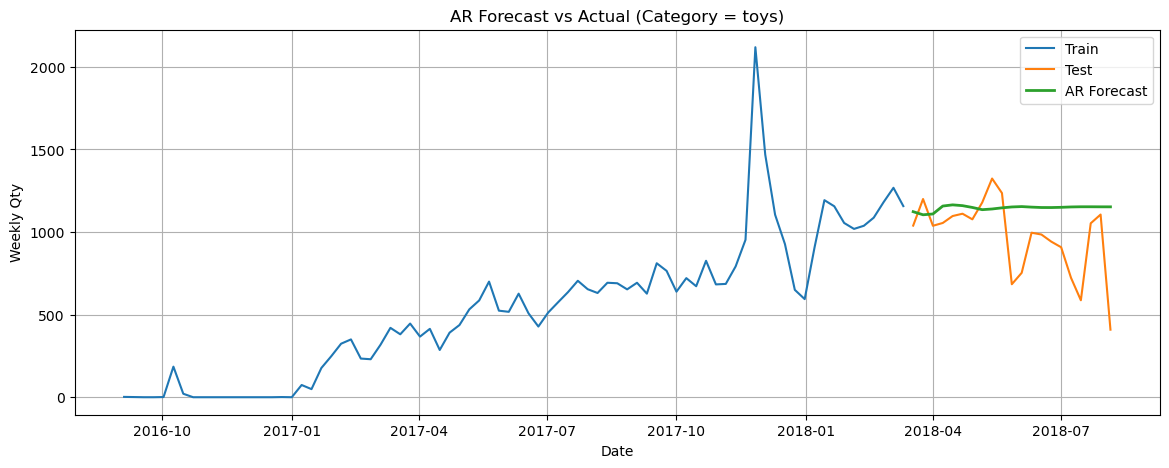

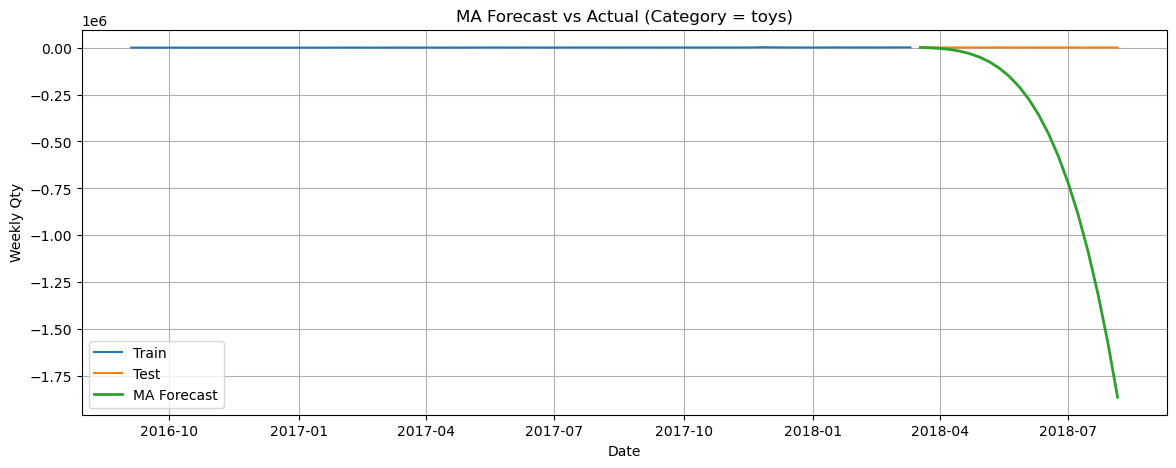

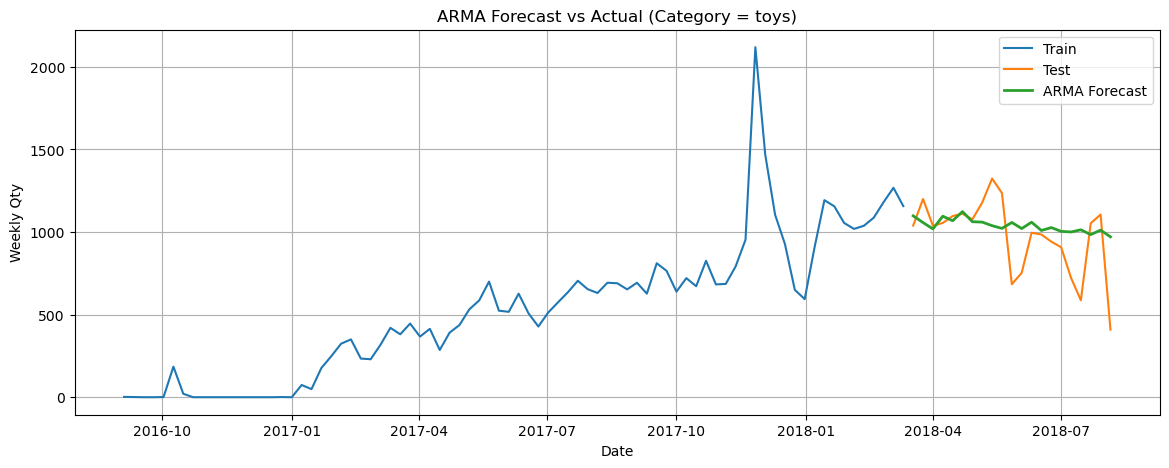

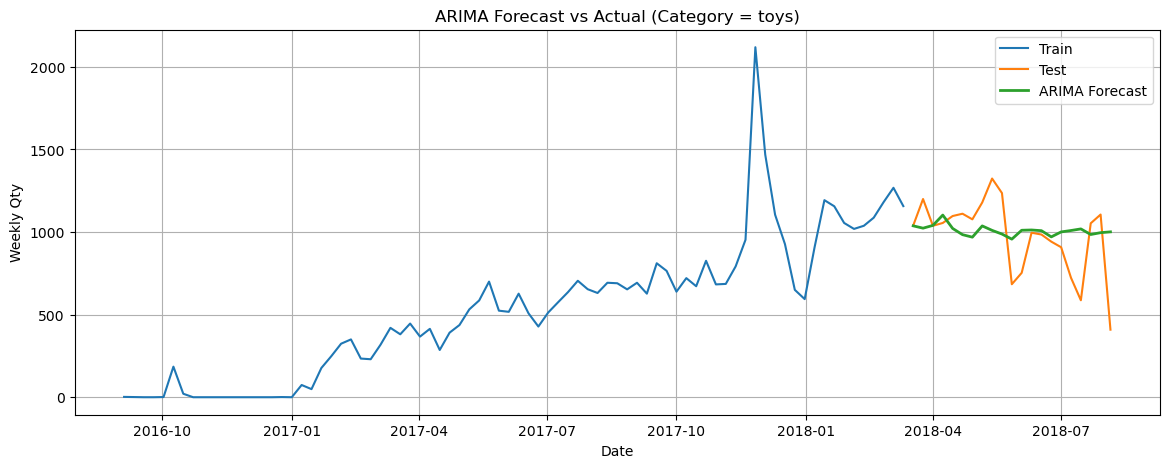

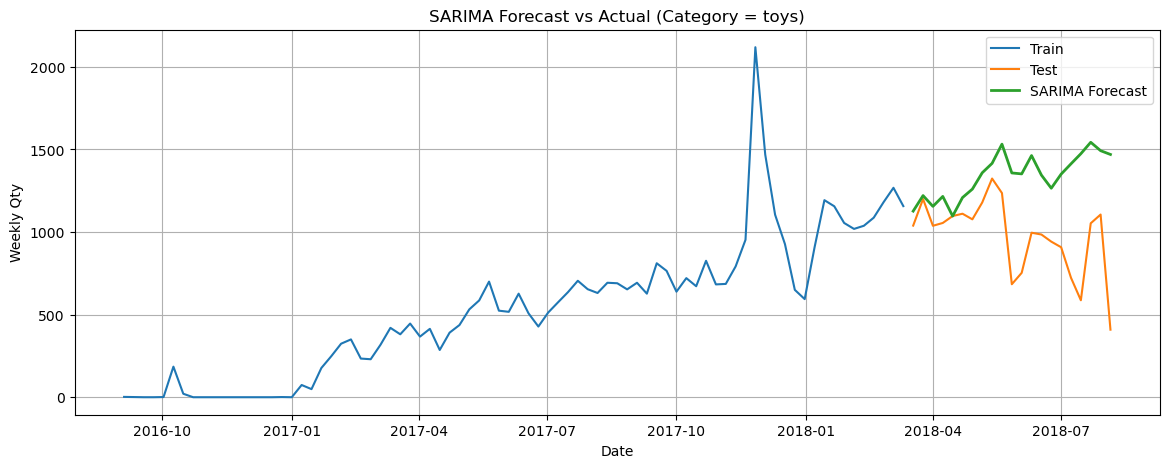

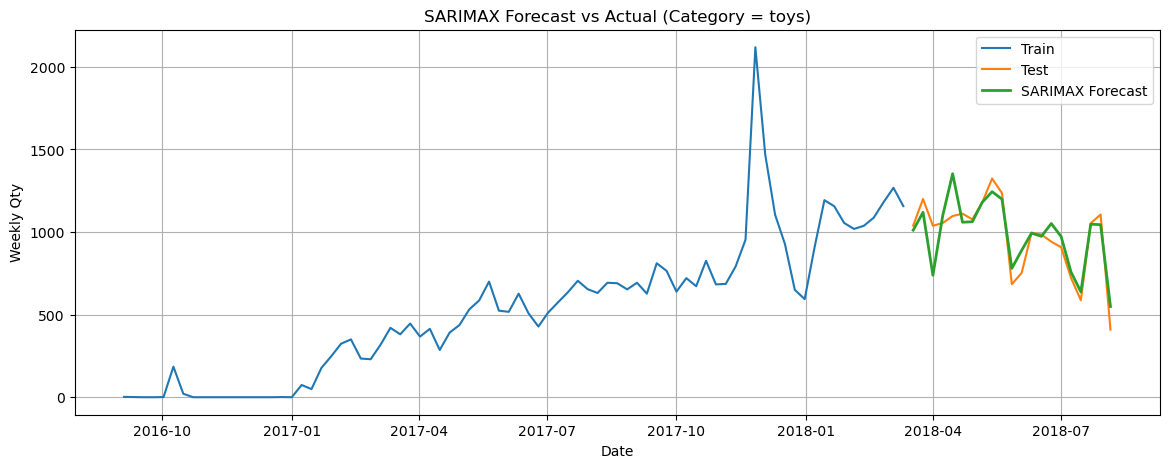

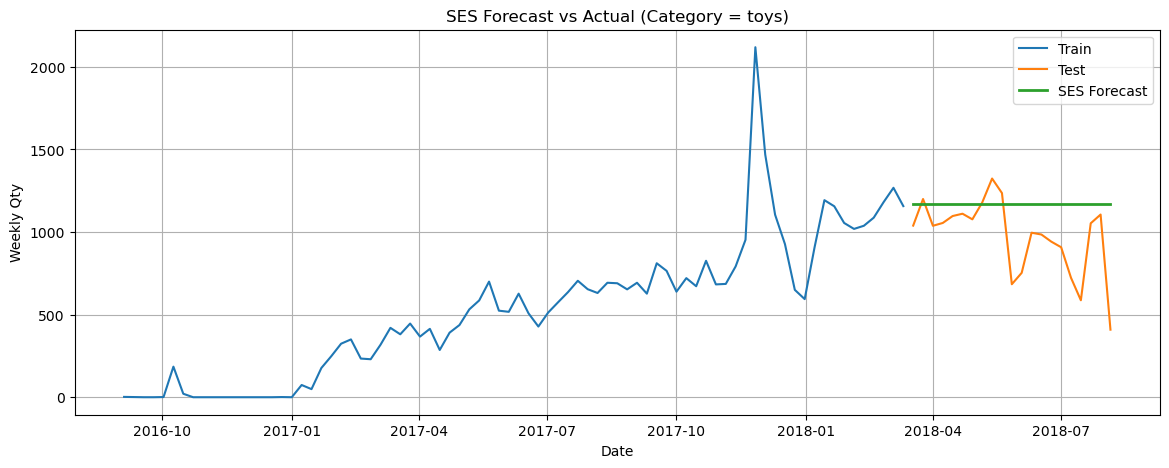

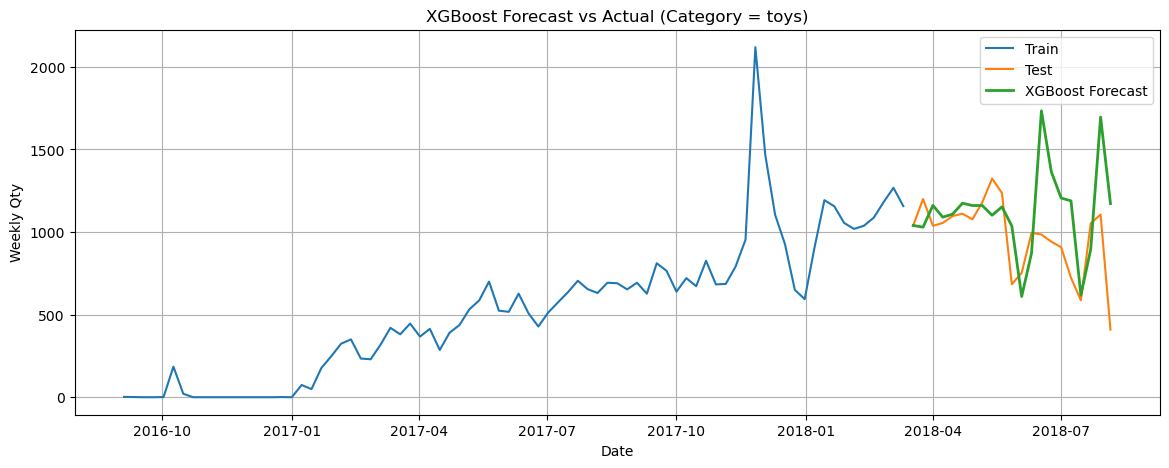

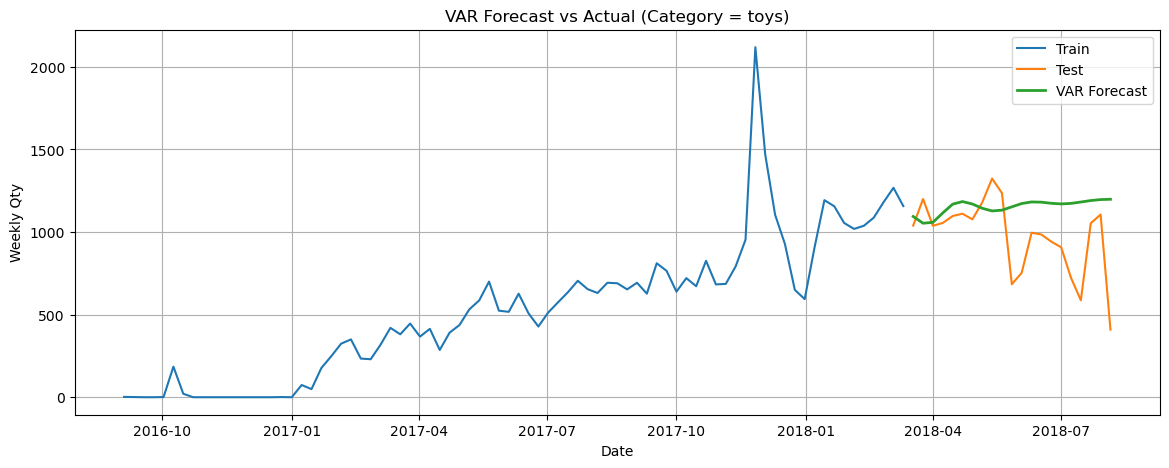

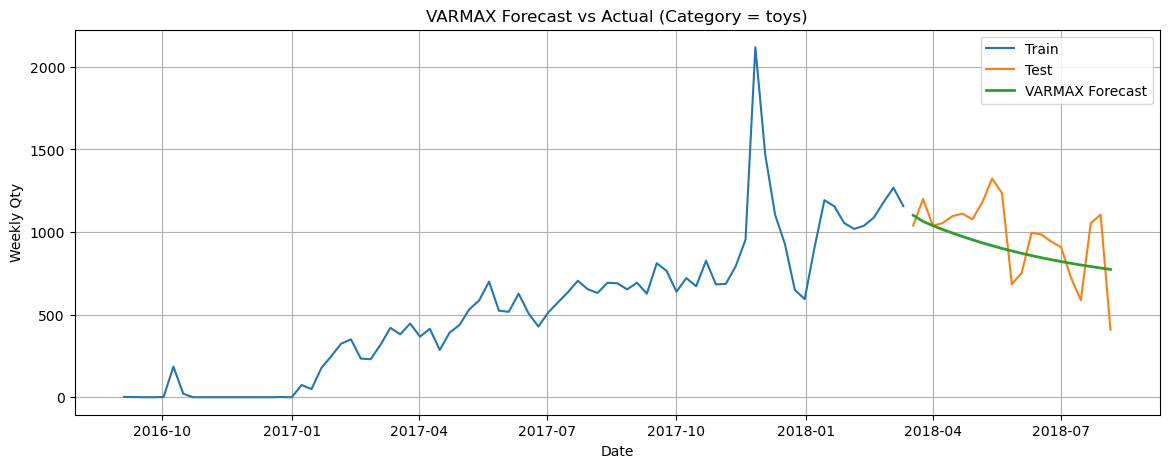

In [14]:
# =========================================================
# PLOT FORECASTS FOR ALL MODELS
# =========================================================
import matplotlib.pyplot as plt

CATEGORY = locals().get("CATEGORY", "toys")

# Helper to plot a model forecast if it exists
def plot_model_forecast(model_name, forecast_values):
    plt.figure(figsize=(14, 5))
    plt.plot(train.index, train['qty'], label='Train', linewidth=1.5)
    plt.plot(test.index, test['qty'], label='Test', linewidth=1.5)

    # forecast
    plt.plot(test.index, forecast_values, label=f'{model_name} Forecast', linewidth=2)

    plt.title(f"{model_name} Forecast vs Actual (Category = {CATEGORY})")
    plt.xlabel("Date")
    plt.ylabel("Weekly Qty")
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================
# 1) AR
# =========================
if 'ar_pred' in locals():
    plot_model_forecast("AR", ar_pred.values)

# =========================
# 2) MA
# =========================
if 'ma_pred' in locals():
    plot_model_forecast("MA", ma_pred)

# =========================
# 3) ARMA
# =========================
if 'arma_pred' in locals():
    plot_model_forecast("ARMA", arma_pred)

# =========================
# 4) ARIMA
# =========================
if 'arima_pred' in locals():
    plot_model_forecast("ARIMA", arima_pred)

# =========================
# 5) SARIMA
# =========================
if 'sarima_pred' in locals():
    plot_model_forecast("SARIMA", sarima_pred)

# =========================
# 6) SARIMAX
# =========================
if 'sarimax_pred' in locals():
    plot_model_forecast("SARIMAX", sarimax_pred)

# =========================
# 7) Simple Exponential Smoothing
# =========================
if 'ses_pred' in locals():
    plot_model_forecast("SES", ses_pred)

# =========================
# 8) Holt–Winters
# =========================
if 'hwes_pred' in locals():
    plot_model_forecast("HWES", hwes_pred)

# =========================
# 9) XGBoost
# (only aligned_pred if available)
# =========================
if 'aligned_pred' in locals() and 'common_idx' in locals():
    plot_model_forecast("XGBoost", pd.Series(aligned_pred, index=common_idx))

# =========================
# 10) VAR
# =========================
if 'var_pred' in locals():
    plot_model_forecast("VAR", var_pred)

# =========================
# 11) VARMAX
# =========================
if 'varmax_for' in locals():
    plot_model_forecast("VARMAX", varmax_for.iloc[:, 0].values)

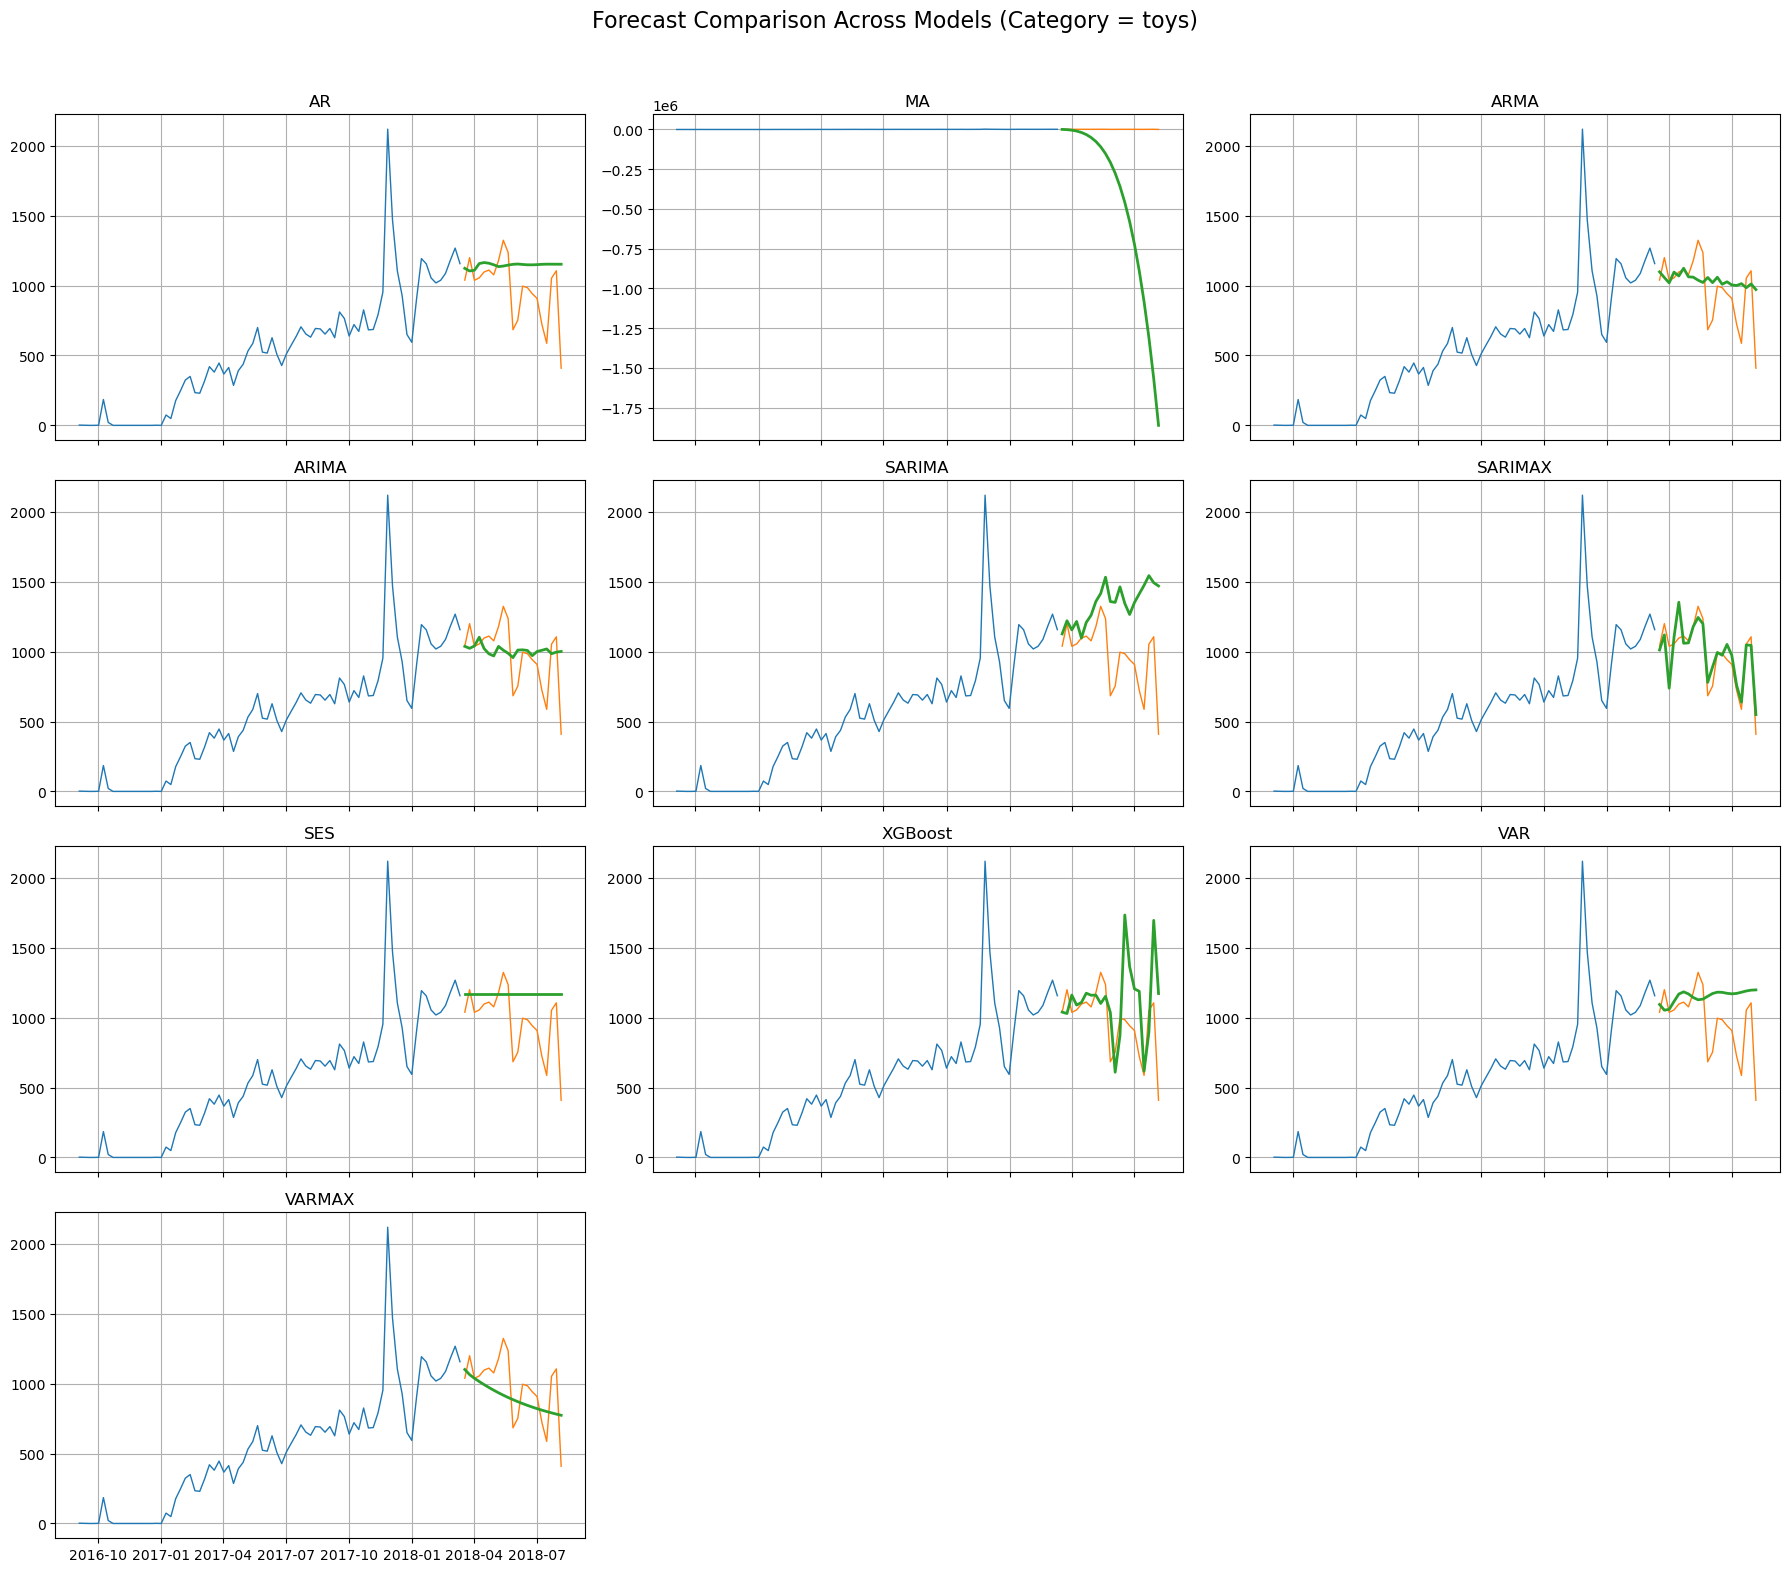

In [15]:
import matplotlib.pyplot as plt
import math

CATEGORY = locals().get("CATEGORY", "toys")

# Collect models dynamically
models = []

if 'ar_pred' in locals():
    models.append(("AR", ar_pred.values))
if 'ma_pred' in locals():
    models.append(("MA", ma_pred))
if 'arma_pred' in locals():
    models.append(("ARMA", arma_pred))
if 'arima_pred' in locals():
    models.append(("ARIMA", arima_pred))
if 'sarima_pred' in locals():
    models.append(("SARIMA", sarima_pred))
if 'sarimax_pred' in locals():
    models.append(("SARIMAX", sarimax_pred))
if 'ses_pred' in locals():
    models.append(("SES", ses_pred))
if 'hwes_pred' in locals():
    models.append(("HWES", hwes_pred))
if 'aligned_pred' in locals() and 'common_idx' in locals():
    models.append(("XGBoost", pd.Series(aligned_pred, index=common_idx)))
if 'var_pred' in locals():
    models.append(("VAR", var_pred))
if 'varmax_for' in locals():
    models.append(("VARMAX", varmax_for.iloc[:, 0].values))

# Grid size
n_cols = 3
n_rows = math.ceil(len(models) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), sharex=True)
axes = axes.flatten()

for i, (name, forecast) in enumerate(models):
    ax = axes[i]
    ax.plot(train.index, train['qty'], label='Train', linewidth=1)
    ax.plot(test.index, test['qty'], label='Test', linewidth=1)
    ax.plot(test.index, forecast, label='Forecast', linewidth=2)

    ax.set_title(name)
    ax.grid(True)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Forecast Comparison Across Models (Category = {CATEGORY})", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## SARIMAX Weekly model with grid search, brazillian holiday added and log transform for No. of Orders

Preparing weekly data and exogenous features...
Running SARIMAX grid search (AIC)...
Best params (order, seasonal): ((0, 1, 0), (1, 0, 0, 52))
Metrics: {'RMSE': 131.3925499779887, 'MAE': 111.77046643375368, 'MAPE': 14.103035943909447}


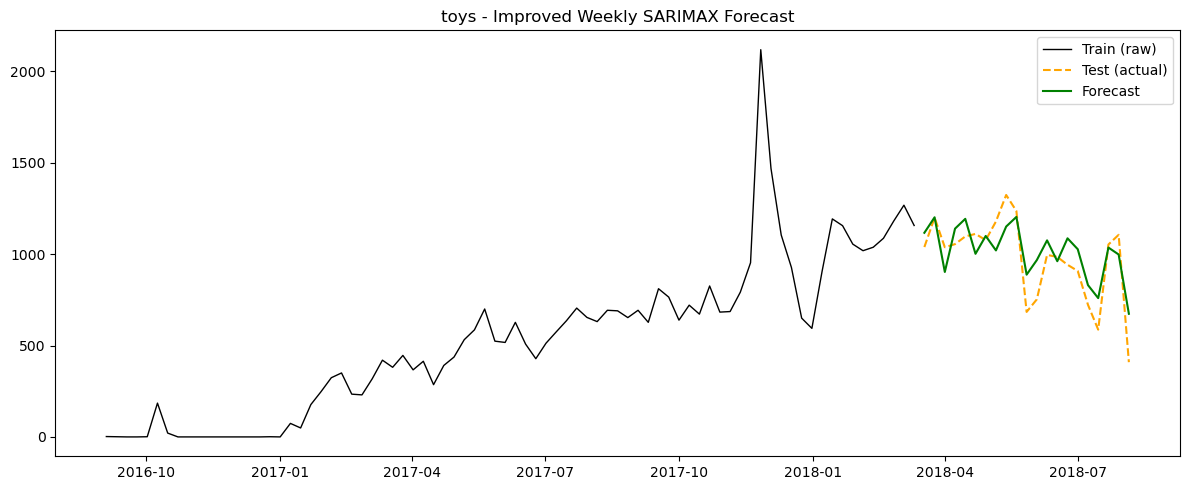

{'RMSE': 131.3925499779887, 'MAE': 111.77046643375368, 'MAPE': 14.103035943909447}


week
2018-03-18    1117.038284
2018-03-25    1201.891443
2018-04-01     902.588829
2018-04-08    1139.790586
2018-04-15    1193.391685
Freq: W-SUN, Name: pred_qty, dtype: float64

In [16]:
# Improved weekly SARIMAX pipeline for 'toys' category
# - log1p transform
# - grid search (AIC)
# - local outlier smoothing (median in window)
# - Brazilian holidays + Children Day + Black Friday + Mother's Day
# - rolling mean/diff exog features
# - weekly aggregation (W-SUN)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt

# -------------------------
# Metrics
# -------------------------
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_metrics(y_true, y_pred):
    return {
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "MAPE": mape(y_true, y_pred)
    }

# -------------------------
# Helper: compute Black Friday (day after 4th Thursday of Nov)
# -------------------------
def compute_black_friday(year):
    # find all days in November for that year
    nov = pd.date_range(start=f"{year}-11-01", end=f"{year}-11-30", freq="D")
    # Thursday is weekday==3
    thursdays = nov[nov.weekday == 3]
    if len(thursdays) >= 4:
        thanksgiving = thursdays[3]  # 0-based -> 4th Thursday
        bf = thanksgiving + pd.Timedelta(days=1)
        return bf.date()
    else:
        return None

# -------------------------
# Helper: compute Mother's Day (2nd Sunday in May)
# -------------------------
def compute_mothers_day(year):
    may = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="D")
    sundays = may[may.weekday == 6]
    if len(sundays) >= 2:
        return sundays[1].date()
    else:
        return None

# -------------------------
# Prepare weekly toys data with holidays and extra exogs
# -------------------------
def prepare_weekly_toys(df, category_name='toys', date_col='order_date', category_col='product_category_name', qty_col=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    if qty_col is None:
        df['_qty_tmp'] = 1
        qty_col = '_qty_tmp'

    # filter category
    df_cat = df[df[category_col] == category_name].copy()

    # weekly aggregation (W-SUN) - use resample on date column
    weekly = df_cat.resample('W-SUN', on=date_col).agg(
        qty=(qty_col, 'sum'),
        avg_price=('price', 'mean') if 'price' in df_cat.columns else (qty_col, 'sum'),
        avg_shipping_charges=('shipping_charges', 'mean') if 'shipping_charges' in df_cat.columns else (qty_col, 'sum')
    ).sort_index()

    # ensure continuous weekly index
    idx = pd.date_range(start=weekly.index.min(), end=weekly.index.max(), freq='W-SUN')
    weekly = weekly.reindex(idx)
    weekly.index.name = 'week'
    weekly['qty'] = weekly['qty'].fillna(0)

    # Build holiday set using python-holidays for Brazil and add custom retail days
    try:
        import holidays
    except Exception as e:
        raise ImportError("Install python-holidays: pip install holidays")

    yrs = list(range(weekly.index.year.min(), weekly.index.year.max()+1))
    br_hols = holidays.Brazil(years=yrs)

    # Collect holiday dates (as date objects)
    hol_dates = set(br_hols.keys())

    # Add Children Day (Dia das Crianças) - Oct 12
    for y in yrs:
        hol_dates.add(pd.Timestamp(f"{y}-10-12").date())

    # Add Black Friday (computed)
    for y in yrs:
        bf = compute_black_friday(y)
        if bf is not None:
            hol_dates.add(bf)

    # Add Mother's Day (2nd Sunday of May)
    for y in yrs:
        md = compute_mothers_day(y)
        if md is not None:
            hol_dates.add(md)

    # Create daily index covering needed range to aggregate holiday presence to week-ending date
    daily = pd.DataFrame(index=pd.date_range(start=weekly.index.min() - pd.Timedelta(days=6),
                                            end=weekly.index.max(), freq='D'))
    daily['is_hol'] = daily.index.to_series().dt.date.isin(hol_dates).astype(int)
    # create week_end mapping (period W-SUN end_time normalized to date)
    daily['week_end'] = daily.index.to_series().dt.to_period('W-SUN').apply(lambda r: r.end_time.normalize())
    weekly_holiday = daily.groupby('week_end')['is_hol'].max().reindex(weekly.index, fill_value=0).astype(int)
    weekly['is_holiday_week'] = weekly_holiday.values

    # Rolling features: rolling mean 4 & 8 weeks, diff
    weekly['roll_mean_4'] = weekly['qty'].rolling(4, min_periods=1).mean()
    weekly['roll_mean_8'] = weekly['qty'].rolling(8, min_periods=1).mean()
    weekly['roll_diff_1'] = weekly['qty'].diff().fillna(0)
    weekly['roll_diff_4'] = weekly['qty'].diff(4).fillna(0)

    # Fill avg_price/avg_shipping if present
    if 'avg_price' in weekly.columns:
        weekly['avg_price'] = weekly['avg_price'].fillna(0)
    if 'avg_shipping_charges' in weekly.columns:
        weekly['avg_shipping_charges'] = weekly['avg_shipping_charges'].fillna(0)

    # exog candidates
    exog_cols = ['is_holiday_week', 'roll_mean_4', 'roll_mean_8', 'roll_diff_1', 'roll_diff_4']
    # include price/shipping if present
    if 'avg_price' in weekly.columns:
        exog_cols.append('avg_price')
    if 'avg_shipping_charges' in weekly.columns:
        exog_cols.append('avg_shipping_charges')

    # final fill for exogs
    weekly[exog_cols] = weekly[exog_cols].fillna(0)

    return weekly, exog_cols

# -------------------------
# Local median-based outlier smoothing
# Replace extreme spikes by local median within window (keeps seasonality)
# -------------------------
def local_median_smooth(series, window=9, threshold_mult=3.0):
    s = series.copy()
    # rolling median centered
    rolling_med = s.rolling(window, center=True, min_periods=1).median()
    # identify spikes as > threshold_mult * local_median
    mask_high = s > (rolling_med * threshold_mult + 1e-9)
    # also lower extreme if needed:
    mask_low  = s < (rolling_med / (threshold_mult) - 1e-9)
    s[mask_high | mask_low] = rolling_med[mask_high | mask_low]
    return s

# -------------------------
# Train/test split
# -------------------------
def train_test_split_by_time(df, test_ratio=0.2):
    n = len(df)
    test_n = max(1, int(np.ceil(n * test_ratio)))
    train = df.iloc[:-test_n].copy()
    test  = df.iloc[-test_n:].copy()
    return train, test

# -------------------------
# SARIMAX grid search (AIC) - modest grid
# -------------------------
def sarimax_grid_search(train_y, train_exog=None, seasonal_period=52,
                        p_vals=[0,1,2], d_vals=[1], q_vals=[0,1,2],
                        P_vals=[0,1], D_vals=[0,1], Q_vals=[0,1],
                        maxiter=50):
    best_aic = np.inf
    best_model = None
    best_params = None
    for p in p_vals:
        for d in d_vals:
            for q in q_vals:
                for P in P_vals:
                    for D in D_vals:
                        for Q in Q_vals:
                            try:
                                model = SARIMAX(train_y,
                                                exog=train_exog,
                                                order=(p,d,q),
                                                seasonal_order=(P,D,Q,seasonal_period),
                                                enforce_stationarity=False,
                                                enforce_invertibility=False).fit(disp=False, maxiter=maxiter)
                                if model.aic < best_aic:
                                    best_aic = model.aic
                                    best_model = model
                                    best_params = ((p,d,q),(P,D,Q,seasonal_period))
                            except Exception:
                                continue
    return best_model, best_params

# -------------------------
# Main pipeline
# -------------------------
def run_improved_weekly_sarimax_toys(df,
                                     category_name='toys',
                                     test_ratio=0.2,
                                     seasonal_period=52,
                                     do_log=True,
                                     do_local_smooth=True,
                                     smoothing_window=9,
                                     smoothing_thresh=3.0,
                                     plot=True):
    print("Preparing weekly data and exogenous features...")
    weekly, exog_cols = prepare_weekly_toys(df, category_name=category_name)

    train, test = train_test_split_by_time(weekly, test_ratio=test_ratio)

    # Apply local smoothing on training qty only
    if do_local_smooth:
        train = train.copy()
        train['qty_smooth'] = local_median_smooth(train['qty'], window=smoothing_window, threshold_mult=smoothing_thresh)
        y_train_raw = train['qty_smooth']
    else:
        y_train_raw = train['qty']

    # log transform (stabilize variance)
    if do_log:
        y_train = np.log1p(y_train_raw)
    else:
        y_train = y_train_raw

    # train exog / test exog
    if len(exog_cols) > 0:
        train_exog = train[exog_cols].astype(float)
        test_exog  = test[exog_cols].astype(float)
    else:
        train_exog, test_exog = None, None

    # Grid search
    print("Running SARIMAX grid search (AIC)...")
    best_model, best_params = sarimax_grid_search(y_train, train_exog=train_exog, seasonal_period=seasonal_period)
    if best_model is None:
        print("No model fit. Try expanding grid or inspect data.")
        return None, None

    print("Best params (order, seasonal):", best_params)
    # Forecast on transformed scale
    steps = len(test)
    try:
        forecast_trans = best_model.forecast(steps=steps, exog=test_exog)
    except Exception as e:
        print("Forecast error:", e)
        return None, None

    # inverse transform
    if do_log:
        # optional bias correction using sigma2
        sigma2 = getattr(best_model, 'sigma2', None)
        if sigma2 is not None:
            # bias correction factor: exp(0.5*sigma2) (approx). apply on log-scale predictions
            bias_corr = np.exp(0.5 * sigma2)
        else:
            bias_corr = 1.0
        pred = np.expm1(forecast_trans) * bias_corr
        # ensure non-negative
        pred = np.clip(pred, 0, None)
    else:
        pred = forecast_trans

    actual = test['qty'].values
    metrics = compute_metrics(actual, pred)
    print("Metrics:", metrics)

    # Plot
    if plot:
        plt.figure(figsize=(12,5))
        plt.plot(train.index, train['qty'], label='Train (raw)', color='black', linewidth=1)
        plt.plot(test.index, test['qty'], label='Test (actual)', color='orange', linestyle='--')
        plt.plot(test.index, pred, label='Forecast', color='green')
        plt.title(f"{category_name} - Improved Weekly SARIMAX Forecast")
        plt.legend()
        plt.tight_layout()
        plt.show()

    pred_series = pd.Series(pred, index=test.index, name='pred_qty')
    return metrics, pred_series, best_model

# -------------------------
# Usage:
metrics, preds, model = run_improved_weekly_sarimax_toys(full_data_final, category_name='toys', test_ratio=0.2)
print(metrics)
preds.head()

In [17]:
# ## Only for toys
# metrics, preds, model = run_improved_weekly_sarimax_toys(full_data_final, category_name='toys', test_ratio=0.2)
# print(metrics)
# preds.head()

## Literature Gap 

Baseline Metrics: {'RMSE': 490.63832385743586, 'MAE': 321.37616139058144, 'MAPE': 33.15842698124915}


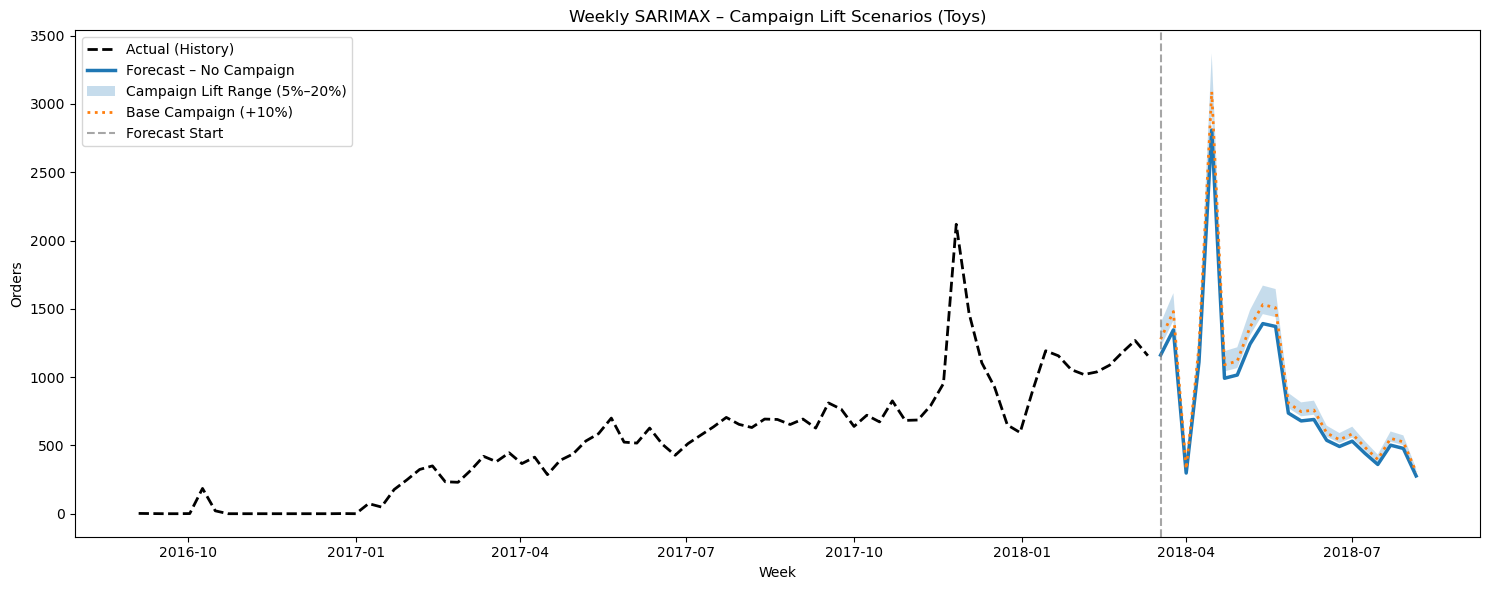

In [18]:
# ============================================================
# WEEKLY SARIMAX (TOYS) + MULTI-CAMPAIGN SCENARIOS (FINAL)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt
import holidays

# ============================================================
# Metrics
# ============================================================
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan

def compute_metrics(y_true, y_pred):
    return {
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "MAPE": mape(y_true, y_pred)
    }

# ============================================================
# Retail calendar helpers
# ============================================================
def compute_black_friday(year):
    nov = pd.date_range(f"{year}-11-01", f"{year}-11-30", freq="D")
    thanksgiving = nov[nov.weekday == 3][3]
    return (thanksgiving + pd.Timedelta(days=1)).date()

def compute_mothers_day(year):
    may = pd.date_range(f"{year}-05-01", f"{year}-05-31", freq="D")
    return may[may.weekday == 6][1].date()

# ============================================================
# Local outlier smoothing
# ============================================================
def local_median_smooth(series, window=9, thresh=3.0):
    s = series.copy()
    med = s.rolling(window, center=True, min_periods=1).median()
    mask = (s > med * thresh) | (s < med / thresh)
    s[mask] = med[mask]
    return s

# ============================================================
# Prepare weekly toys data
# ============================================================
def prepare_weekly_toys(df, category='toys'):

    df = df.copy()
    df['order_date'] = pd.to_datetime(df['order_date'])
    df = df[df['product_category_name'] == category]

    weekly = (
        df.resample('W-SUN', on='order_date')
          .size()
          .to_frame('qty')
          .asfreq('W-SUN', fill_value=0)
    )

    # ---- Holidays
    years = range(weekly.index.year.min(), weekly.index.year.max() + 1)
    br_holidays = holidays.Brazil(years=years)
    hols = set(br_holidays.keys())

    for y in years:
        hols.add(pd.Timestamp(f"{y}-10-12").date())     # Children's Day
        hols.add(compute_black_friday(y))
        hols.add(compute_mothers_day(y))

    daily = pd.DataFrame(
        index=pd.date_range(
            weekly.index.min() - pd.Timedelta(days=6),
            weekly.index.max(),
            freq='D'
        )
    )

    daily['is_holiday'] = (
        pd.Series(daily.index.date, index=daily.index)
        .isin(hols)
        .astype(int)
    )

    daily['week_end'] = daily.index.to_period('W-SUN').end_time.normalize()
    weekly['is_holiday_week'] = (
        daily.groupby('week_end')['is_holiday']
             .max()
             .reindex(weekly.index, fill_value=0)
    )

    # ---- Rolling features
    weekly['roll_mean_4'] = weekly['qty'].rolling(4, min_periods=1).mean()
    weekly['roll_mean_8'] = weekly['qty'].rolling(8, min_periods=1).mean()
    weekly['roll_diff_1'] = weekly['qty'].diff().fillna(0)
    weekly['roll_diff_4'] = weekly['qty'].diff(4).fillna(0)

    exog_cols = [
        'is_holiday_week',
        'roll_mean_4',
        'roll_mean_8',
        'roll_diff_1',
        'roll_diff_4'
    ]

    weekly[exog_cols] = weekly[exog_cols].fillna(0)

    return weekly, exog_cols

# ============================================================
# SARIMAX grid search
# ============================================================
def sarimax_grid_search(y, X, seasonal_period=52):

    best_aic = np.inf
    best_model = None

    for p in [0,1,2]:
        for q in [0,1,2]:
            for P in [0,1]:
                for Q in [0,1]:
                    try:
                        model = SARIMAX(
                            y, exog=X,
                            order=(p,1,q),
                            seasonal_order=(P,1,Q,seasonal_period),
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        ).fit(disp=False)

                        if model.aic < best_aic:
                            best_aic = model.aic
                            best_model = model
                    except:
                        pass

    return best_model

# ============================================================
# MAIN PIPELINE
# ============================================================
def run_weekly_sarimax_multi_campaign(df):

    weekly, exog_cols = prepare_weekly_toys(df)

    # ---- Train / Test split
    n_test = int(np.ceil(len(weekly) * 0.2))
    train, test = weekly.iloc[:-n_test], weekly.iloc[-n_test:]

    # ---- Outlier smoothing
    train['qty_smooth'] = local_median_smooth(train['qty'])

    # ---- Log transform
    y_train = np.log1p(train['qty_smooth'])

    X_train = train[exog_cols]
    X_test  = test[exog_cols]

    # ---- Fit model
    model = sarimax_grid_search(y_train, X_train)

    # ---- Baseline forecast (log scale)
    f_log = model.forecast(len(test), exog=X_test)

    # ---- Bias correction
    sigma2 = np.nanvar(model.resid)
    bias = np.exp(0.5 * sigma2)

    pred_base = np.clip(np.expm1(f_log) * bias, 0, None)

    # ======================================================
    # Campaign scenarios (future only)
    # ======================================================
    scenarios = {
        "No Campaign": 0.00,
        "Low (+5%)": 0.05,
        "Base (+10%)": 0.10,
        "High (+20%)": 0.20
    }

    preds = {k: pred_base * (1 + v) for k, v in scenarios.items()}

    # ---- Metrics (baseline vs actual)
    metrics = compute_metrics(test['qty'].values, pred_base)
    print("Baseline Metrics:", metrics)

    # ======================================================
    # PLOT (CORRECT & CLEAN)
    # ======================================================
    plt.figure(figsize=(15,6))


    # ---- Actuals (TRAIN period only)
    plt.plot(
    train.index,
    train['qty'],
    linestyle='--',
    linewidth=2,
    color='black',
    label='Actual (History)'
    )


    # ---- Baseline forecast (future only)
    plt.plot(
        test.index,
        preds['No Campaign'],
        linewidth=2.5,
        label='Forecast – No Campaign'
    )

    # ---- Campaign uplift band
    plt.fill_between(
        test.index,
        preds['Low (+5%)'],
        preds['High (+20%)'],
        alpha=0.25,
        label='Campaign Lift Range (5%–20%)'
    )

    # ---- Base campaign line
    plt.plot(
        test.index,
        preds['Base (+10%)'],
        linestyle=':',
        linewidth=2,
        label='Base Campaign (+10%)'
    )

    # ---- Forecast start marker
    plt.axvline(
        x=test.index[0],
        linestyle='--',
        color='gray',
        alpha=0.7,
        label='Forecast Start'
    )

    plt.title("Weekly SARIMAX – Campaign Lift Scenarios (Toys)")
    plt.xlabel("Week")
    plt.ylabel("Orders")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return metrics, preds, model

# ============================================================
# USAGE
# ============================================================
metrics, scenario_forecasts, model = run_weekly_sarimax_multi_campaign(full_data_final)

## Panel Interactive Dashboard

In [19]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def compute_metrics(y_true, y_pred):
    return {
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "MAPE": mape(y_true, y_pred)
    }
def compute_black_friday(year):
    nov = pd.date_range(start=f"{year}-11-01", end=f"{year}-11-30", freq="D")
    thursdays = nov[nov.weekday == 3]
    return (thursdays[3] + pd.Timedelta(days=1)).date() if len(thursdays) >= 4 else None


def compute_mothers_day(year):
    may = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="D")
    sundays = may[may.weekday == 6]
    return sundays[1].date() if len(sundays) >= 2 else None
def prepare_weekly_data(
    df,
    category_name,
    date_col='order_date',
    category_col='product_category_name'
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # order count = 1 per row
    df['_qty_'] = 1
    df = df[df[category_col] == category_name]

    weekly = (
        df.resample('W-SUN', on=date_col)
          .agg(qty=('_qty_', 'sum'))
          .sort_index()
    )

    # continuous weekly index
    idx = pd.date_range(weekly.index.min(), weekly.index.max(), freq='W-SUN')
    weekly = weekly.reindex(idx, fill_value=0)
    weekly.index.name = 'week'

    # ---------------- Holidays ----------------
    import holidays
    yrs = range(weekly.index.year.min(), weekly.index.year.max() + 1)
    br_holidays = holidays.Brazil(years=yrs)

    hol_dates = set(br_holidays.keys())
    for y in yrs:
        hol_dates.add(pd.Timestamp(f"{y}-10-12").date())  # Children's Day
        bf = compute_black_friday(y)
        md = compute_mothers_day(y)
        if bf: hol_dates.add(bf)
        if md: hol_dates.add(md)

    daily = pd.DataFrame(index=pd.date_range(
        weekly.index.min() - pd.Timedelta(days=6),
        weekly.index.max(),
        freq='D'
    ))
    daily['is_holiday'] = (
    pd.Series(daily.index.date, index=daily.index)
      .isin(hol_dates)
      .astype(int)
)
    daily['week'] = daily.index.to_period('W-SUN').end_time

    weekly['is_holiday_week'] = (
        daily.groupby('week')['is_holiday']
             .max()
             .reindex(weekly.index, fill_value=0)
    )

    # rolling features
    weekly['roll_mean_4'] = weekly['qty'].rolling(4, min_periods=1).mean()
    weekly['roll_mean_8'] = weekly['qty'].rolling(8, min_periods=1).mean()
    weekly['diff_1'] = weekly['qty'].diff().fillna(0)
    weekly['diff_4'] = weekly['qty'].diff(4).fillna(0)

    exog_cols = [
        'is_holiday_week',
        'roll_mean_4',
        'roll_mean_8',
        'diff_1',
        'diff_4'
    ]

    weekly[exog_cols] = weekly[exog_cols].fillna(0)

    return weekly, exog_cols
def local_median_smooth(series, window=9, threshold=3.0):
    med = series.rolling(window, center=True, min_periods=1).median()
    upper = med * threshold
    lower = med / threshold
    s = series.copy()
    s[(s > upper) | (s < lower)] = med[(s > upper) | (s < lower)]
    return s
def time_split(df, test_ratio=0.2):
    n_test = int(np.ceil(len(df) * test_ratio))
    return df.iloc[:-n_test], df.iloc[-n_test:]
def sarimax_grid_search(y, exog, seasonal_period=52):
    best_aic = np.inf
    best_model = None

    for p in [0,1,2]:
        for d in [1]:
            for q in [0,1,2]:
                for P in [0,1]:
                    for D in [0,1]:
                        for Q in [0,1]:
                            try:
                                model = SARIMAX(
                                    y,
                                    exog=exog,
                                    order=(p,d,q),
                                    seasonal_order=(P,D,Q,seasonal_period),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                if model.aic < best_aic:
                                    best_aic = model.aic
                                    best_model = model
                            except:
                                continue

    return best_model
def run_category_pipeline(df, category):

    weekly, exog_cols = prepare_weekly_data(df, category)
    train, test = time_split(weekly)

    # smooth + log
    y_train = local_median_smooth(train['qty'])
    y_train_log = np.log1p(y_train)

    train_exog = train[exog_cols]
    test_exog  = test[exog_cols]

    model = sarimax_grid_search(y_train_log, train_exog)

    forecast_log = model.forecast(len(test), exog=test_exog)
    forecast = np.expm1(forecast_log).clip(0)

    metrics = compute_metrics(test['qty'], forecast)

    # ---- tidy output ----
    out = pd.concat([
        pd.DataFrame({
            'date': train.index,
            'category': category,
            'orders': train['qty'].values,
            'flag': 'train'
        }),
        pd.DataFrame({
            'date': test.index,
            'category': category,
            'orders': test['qty'].values,
            'flag': 'actual'
        }),
        pd.DataFrame({
            'date': test.index,
            'category': category,
            'orders': forecast.values,
            'flag': 'forecast'
        })
    ])

    return out, metrics
def get_top_categories(df, category_col='product_category_name', top_n=5):
    return (
        df.groupby(category_col)
          .size()
          .sort_values(ascending=False)
          .head(top_n)
          .index
          .tolist()
    )
top_categories = get_top_categories(full_data_final, top_n=5)

all_ts = []
all_metrics = []

for cat in top_categories:
    print(f"Running category: {cat}")
    ts_df, met = run_category_pipeline(full_data_final, cat)
    all_ts.append(ts_df)
    met['category'] = cat
    all_metrics.append(met)

final_timeseries_df = pd.concat(all_ts, ignore_index=True)
metrics_df = pd.DataFrame(all_metrics)

Running category: toys
Running category: health_beauty
Running category: bed_bath_table
Running category: sports_leisure
Running category: furniture_decor


In [20]:
final_timeseries_df

,date,category,orders,flag
0,2016-09-04,toys,2.000000,train
1,2016-09-11,toys,1.000000,train
2,2016-09-18,toys,0.000000,train
3,2016-09-25,toys,0.000000,train
4,2016-10-02,toys,1.000000,train
...,...,...,...,...
581,2018-07-08,furniture_decor,23.912798,forecast
582,2018-07-15,furniture_decor,15.848939,forecast
583,2018-07-22,furniture_decor,25.244007,forecast
584,2018-07-29,furniture_decor,20.495655,forecast


In [21]:
# Save the dataframe to CSV
final_timeseries_df.to_csv(r"C:\Users\sujay\Desktop\BITS\Semester 4\Codes\final_timeseries_df.csv", index=False)

In [22]:
import panel as pn
import hvplot.pandas  # noqa

pn.extension('tabulator')

# Ensure correct dtypes
df = final_timeseries_df.copy()
df['date'] = pd.to_datetime(df['date'])

# -----------------------------
# Widgets
# -----------------------------
category_selector = pn.widgets.Select(
    name='Category',
    options=sorted(df['category'].unique().tolist())
)

# -----------------------------
# Reactive plot
# -----------------------------
@pn.depends(category_selector)
def line_chart(category):
    dff = df[df['category'] == category]

    return dff.hvplot.line(
        x='date',
        y='orders',
        by='flag',
        linewidth=2,
        height=400,
        width=900,
        legend='top_left',
        title=f'Weekly Orders – {category}',
        ylabel='Orders',
        xlabel='Week'
    )

# -----------------------------
# Layout
# -----------------------------
dashboard = pn.Column(
    "## 📈 SARIMAX Forecast Dashboard",
    pn.Row(category_selector),
    line_chart
)

dashboard

Column
    [0] Markdown(str)
    [1] Row
        [0] Select(name='Category', options=['bed_bath_table', ...], value='bed_bath_table')
    [2] ParamFunction(function, _pane=HoloViews, defer_load=False)

## Campaign Plot - Panel

In [23]:
import pandas as pd
import panel as pn
import hvplot.pandas  # noqa
import holoviews as hv

pn.extension('tabulator')
hv.extension('bokeh')

# -----------------------------
# Copy and prepare dataframe
# -----------------------------
df = final_timeseries_df.copy()
df['date'] = pd.to_datetime(df['date'])

# -----------------------------
# Widgets
# -----------------------------
category_selector = pn.widgets.Select(
    name='Category',
    options=sorted(df['category'].unique())
)

campaign_selector = pn.widgets.Select(
    name='Campaign',
    options={
        "No Campaign (0%)": 0.00,
        "Low Campaign (+5%)": 0.05,
        "Moderate Campaign (+10%)": 0.10,
        "Intense Campaign (+20%)": 0.20
    }
)

# -----------------------------
# Dashboard plotting function
# -----------------------------
@pn.depends(category_selector, campaign_selector)
def campaign_chart(category, uplift):

    # Filter data by category
    dff = df[df['category'] == category].copy()
    train_df = dff[dff['flag'] == 'train']
    forecast_df = dff[dff['flag'] == 'forecast'].copy()

    # Train plot
    train_plot = train_df.hvplot.line(
        x='date',
        y='orders',
        label='Actuals (Train)',
        line_width=2
    )

    # Handle empty forecast
    if forecast_df.empty:
        return train_plot.opts(
            title=f"No Forecast Available – {category}",
            height=450,
            width=900
        )

    # Campaign forecast calculations
    forecast_df['campaign_orders'] = forecast_df['orders'] * (1 + uplift)
    forecast_df['band_low'] = forecast_df['orders'] * 1.05
    forecast_df['band_high'] = forecast_df['orders'] * 1.20

    # Base forecast line
    base_forecast = forecast_df.hvplot.line(
        x='date',
        y='orders',
        label='Base Forecast',
        line_dash='dashed',
        line_width=2
    )

    # Campaign adjusted forecast line
    campaign_plot = forecast_df.hvplot.line(
        x='date',
        y='campaign_orders',
        label=f'Campaign Forecast (+{int(uplift*100)}%)',
        line_width=3
    )

    # Campaign lift band – only if columns exist and non-empty
    if all(col in forecast_df for col in ['band_low', 'band_high']) and not forecast_df[['band_low', 'band_high']].isna().all().all():
        band_plot = hv.Area(
            (forecast_df['date'], forecast_df['band_low'], forecast_df['band_high']),
            kdims='date',
            vdims=['band_low', 'band_high'],
            label='Campaign Lift Band (5%–20%)'
        ).opts(fill_alpha=0.25, line_alpha=0)
    else:
        band_plot = hv.Area([])  # empty placeholder

    # Combine all layers
    plot = (train_plot * band_plot * base_forecast * campaign_plot).opts(
        height=450,
        width=900,
        title=f"Campaign Impact Forecast – {category}",
        xlabel="Week",
        ylabel="Orders",
        legend_position="top_left"
    )

    return plot

# -----------------------------
# Assemble dashboard
# -----------------------------
dashboard = pn.Column(
    "##   Campaign Impact Forecast Dashboard",
    pn.Row(category_selector, campaign_selector),
    campaign_chart
)

dashboard.servable()

Column
    [0] Markdown(str)
    [1] Row
        [0] Select(name='Category', options=['bed_bath_table', ...], value='bed_bath_table')
        [1] Select(name='Campaign', options={'No Campaign (0%)': 0.0, ...}, value=0.0)
    [2] ParamFunction(function, _pane=HoloViews, defer_load=False)

## Setting up Alerts for when Model failure occurs

In [24]:
import panel as pn
import hvplot.pandas
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error

pn.extension()

# Alert pane (red bold text via HTML)
alert = pn.pane.Markdown("", width=800)

# Threshold for MAPE
MAPE_THRESHOLD = 0.15

@pn.depends(category_selector)
def forecast_chart_with_alert(category):

    dff = df[df['category'] == category].copy()
    train_df = dff[dff['flag'] == 'train']
    test_df = dff[dff['flag'] == 'forecast'].copy()

    # Train plot
    train_plot = train_df.hvplot.line(
        x='date',
        y='orders',
        label='Actuals (Train)',
        line_width=2
    )

    # If no test data
    if test_df.empty:
        alert.object = ""
        return train_plot.opts(
            title=f"No Forecast/Test Data Available – {category}",
            height=450,
            width=900
        )

    # Forecast line
    forecast_plot = test_df.hvplot.line(
        x='date',
        y='orders',
        label='Forecast',
        line_dash='dashed',
        line_width=2
    )

    # Accuracy check
    try:
        if 'actual_orders' in test_df.columns:
            mape = mean_absolute_percentage_error(test_df['actual_orders'], test_df['orders'])
        else:
            mape = 0

        if mape > MAPE_THRESHOLD:
            alert.object = f"<b style='color:red'>   Model accuracy has dropped (MAPE = {mape:.2%}). Please remodel the data!</b>"
        else:
            alert.object = ""
    except Exception:
        alert.object = "<b style='color:red'>   Unable to calculate accuracy.</b>"

    # Combine plots
    plot = (train_plot * forecast_plot).opts(
        height=450,
        width=900,
        title=f"Forecast vs Actual – {category}",
        xlabel="Date",
        ylabel="Orders",
        legend_position="top_left"
    )

    return plot

# Dashboard
dashboard = pn.Column(
    "##   Forecast Accuracy Dashboard",
    pn.Row(category_selector),
    alert,
    forecast_chart_with_alert
)

dashboard.servable()

Column
    [0] Markdown(str)
    [1] Row
        [0] Select(name='Category', options=['bed_bath_table', ...], value='bed_bath_table')
    [2] Markdown(str, width=800)
    [3] ParamFunction(function, _pane=HoloViews, defer_load=False)

## Demo - Alert Mechanism for Forecast MAPE exceeding threshold

In [25]:
import pandas as pd
import numpy as np
import panel as pn
import hvplot.pandas
from sklearn.metrics import mean_absolute_percentage_error

pn.extension()

# -----------------------------
# Dummy dataset for "toys" only
# -----------------------------
# Train data
dates = pd.date_range(start='2025-01-01', periods=8, freq='W')
train_orders = np.random.randint(80, 120, size=len(dates))
train_df = pd.DataFrame({
    'date': dates,
    'category': 'toys',
    'orders': train_orders,
    'flag': 'train'
})

# Forecast with exaggerated deviation to exceed MAPE
future_dates = pd.date_range(start=dates.max() + pd.Timedelta(days=7), periods=4, freq='W')
forecast_orders = train_orders.mean() * np.array([1.3, 1.4, 1.2, 1.5])  # intentionally large deviation
forecast_df = pd.DataFrame({
    'date': future_dates,
    'category': 'toys',
    'orders': forecast_orders,
    'flag': 'forecast',
    'actual_orders': train_orders.mean()  # dummy actual for MAPE calculation
})

# Combine into single dataframe
df_toys = pd.concat([train_df, forecast_df], ignore_index=True)

# -----------------------------
# Alert pane
# -----------------------------
alert = pn.pane.Markdown("")

# Threshold for MAPE
MAPE_THRESHOLD = 0.15

# -----------------------------
# Dashboard plotting function
# -----------------------------
def forecast_chart_toys():

    train_df = df_toys[df_toys['flag'] == 'train']
    test_df = df_toys[df_toys['flag'] == 'forecast']

    # Train plot
    train_plot = train_df.hvplot.line(
        x='date',
        y='orders',
        label='Actuals (Train)',
        line_width=2
    )

    # Forecast plot
    forecast_plot = test_df.hvplot.line(
        x='date',
        y='orders',
        label='Forecast',
        line_dash='dashed',
        line_width=2
    )

    # Accuracy check
    try:
        mape = mean_absolute_percentage_error(test_df['actual_orders'], test_df['orders'])
        if mape > MAPE_THRESHOLD:
            alert.object = f"<b style='color:red'>   Model accuracy has dropped (MAPE = {mape:.2%}). Please remodel the data!</b>"
        else:
            alert.object = ""
    except Exception:
        alert.object = "<b style='color:red'>   Unable to calculate accuracy.</b>"

    # Combine plots
    plot = (train_plot * forecast_plot).opts(
        height=450,
        width=900,
        title=f"Forecast vs Actual – Toys",
        xlabel="Date",
        ylabel="Orders",
        legend_position="top_left"
    )

    return plot

# -----------------------------
# Assemble dashboard
# -----------------------------
dashboard = pn.Column(
    "##   Forecast Accuracy Demo – Toys Category",
    alert,
    forecast_chart_toys
)

dashboard.servable()

Column
    [0] Markdown(str)
    [1] Markdown(str)
    [2] Column(sizing_mode='fixed')
        [0] Column()
        [1] Row(sizing_mode='fixed')
            [0] HoloViews(Overlay, height=450, name='interactive01703', sizing_mode='fixed', width=900)